# Classificazione di malattie nelle foglie — PlantVillage

## Obiettivo

Riconoscere le malattie nelle foglie di pomodoro combinando un metodo non supervisionato e uno
supervisionato.

Il lavoro affronta **due fasi**:

1. **Autoencoder** (non supervisionato). Un autoencoder viene addestrato a ricostruire
   *solo foglie sane*

2. **Classificazione XGboost** (supervisionato). Tra 10 condizioni possibili (9 malattie + sana), un classificatore XGBoost assegna il tipo a partire dalle rappresentazioni apprese dall'encoder.

# Configurazione

In [1]:
import os
os.makedirs("ckpt", exist_ok=True)
os.environ["KERAS_BACKEND"] = "torch"

In [2]:
import keras
from keras import Sequential, Input
from keras.layers import Conv2D, MaxPooling2D, UpSampling2D, Rescaling
from keras.optimizers import Adam
from keras.losses import MeanSquaredError
from keras.metrics import MeanAbsoluteError
from keras.activations import leaky_relu
from keras.callbacks import EarlyStopping, ModelCheckpoint

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, glob, random, zipfile
from PIL import Image
from scipy.ndimage import gaussian_filter

import optuna
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from xgboost import XGBClassifier

optuna.logging.set_verbosity(optuna.logging.WARNING)

In [3]:
keras.backend.backend()

'torch'

In [4]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
keras.utils.set_random_seed(SEED)

In [ ]:
KAGGLE_SLUG   = "abdallahalidev/plantvillage-dataset"
BASE_DIR      = "plantvillage"
TARGET_PLANT  = "Tomato"
USE_SEGMENTED = True  
IMG_SIZE      = 128   
BOTTLENECK_CH = 32    
TOPK_FRAC     = 0.02  # frazione di pixel peggiori usata come punteggio di anomalia

# Caricamento del dataset

Le immagini sono organizzate in cartelle nominate `Pianta___Condizione`, dove la condizione è `healthy`
per le foglie sane oppure il nome della malattia. Si usano le immagini a colori. La specie e la condizione
si ricavano dal nome della cartella.

In [6]:
if not os.path.isdir(BASE_DIR):
    candidates = glob.glob("plantvillage-dataset*.zip")
    if not candidates:
        raise FileNotFoundError(
            "Zip non trovato. Scaricalo da Kaggle (abdallahalidev/plantvillage-dataset) "
            "e mettilo nella cartella del notebook."
        )
    with zipfile.ZipFile(candidates[0]) as z:
        z.extractall(BASE_DIR)

In [7]:
target_folder = "segmented" if USE_SEGMENTED else "color"
class_dirs = [d for d in glob.glob(os.path.join(BASE_DIR, "**", "*___*"), recursive=True)
              if os.path.isdir(d)]
parents = {os.path.dirname(d) for d in class_dirs}
chosen = [p for p in parents if os.path.basename(p).lower() == target_folder]
DATA_DIR = chosen[0] if chosen else sorted(parents)[0]
DATA_DIR

'plantvillage\\plantvillage dataset\\segmented'

In [8]:
def parse_class(folder_name):
    """Dal nome cartella 'Pianta___Condizione' ricava (pianta, condizione, sana)."""
    plant, _, condition = folder_name.partition("___")
    plant = plant.split("_(")[0].replace("_", " ").strip()
    healthy = condition.lower() == "healthy"
    return plant, condition, healthy

In [9]:
records = []
for folder in sorted(os.listdir(DATA_DIR)):
    folder_path = os.path.join(DATA_DIR, folder)
    if not os.path.isdir(folder_path) or "___" not in folder:
        continue
    plant, condition, healthy = parse_class(folder)
    for filename in os.listdir(folder_path):
        if filename.lower().endswith((".jpg", ".jpeg", ".png")):
            records.append({"path": os.path.join(folder_path, filename),
                            "plant": plant, "condition": condition, "healthy": healthy})

df = pd.DataFrame(records)

In [10]:
print("Immagini totali:", len(df))
print("Specie:", df["plant"].nunique())
print("Classi:", df["condition"].nunique())
df.head()

Immagini totali: 54306
Specie: 14
Classi: 21


,path,plant,condition,healthy
0,plantvillage\plantvillage dataset\segmented\Ap...,Apple,Apple_scab,False
1,plantvillage\plantvillage dataset\segmented\Ap...,Apple,Apple_scab,False
2,plantvillage\plantvillage dataset\segmented\Ap...,Apple,Apple_scab,False
3,plantvillage\plantvillage dataset\segmented\Ap...,Apple,Apple_scab,False
4,plantvillage\plantvillage dataset\segmented\Ap...,Apple,Apple_scab,False


# Panoramica del dataset

Numerosità per specie, proporzione sane/malate e distribuzione delle condizioni del pomodoro, la specie con
più malattie distinte e quindi la più adatta per entrambe le analisi.

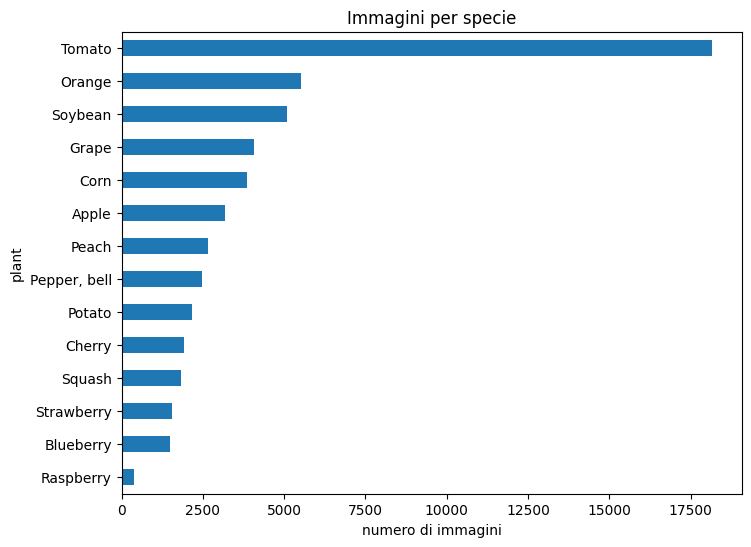

In [11]:
df["plant"].value_counts().sort_values().plot.barh(figsize=(8, 6), title="Immagini per specie")
plt.xlabel("numero di immagini")
plt.show()

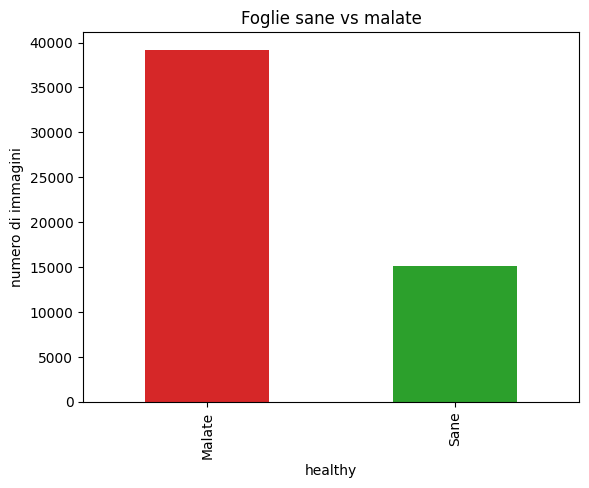

In [12]:
counts = df["healthy"].map({True: "Sane", False: "Malate"}).value_counts()
counts.plot.bar(title="Foglie sane vs malate", color=["#d62728", "#2ca02c"])
plt.ylabel("numero di immagini")
plt.show()

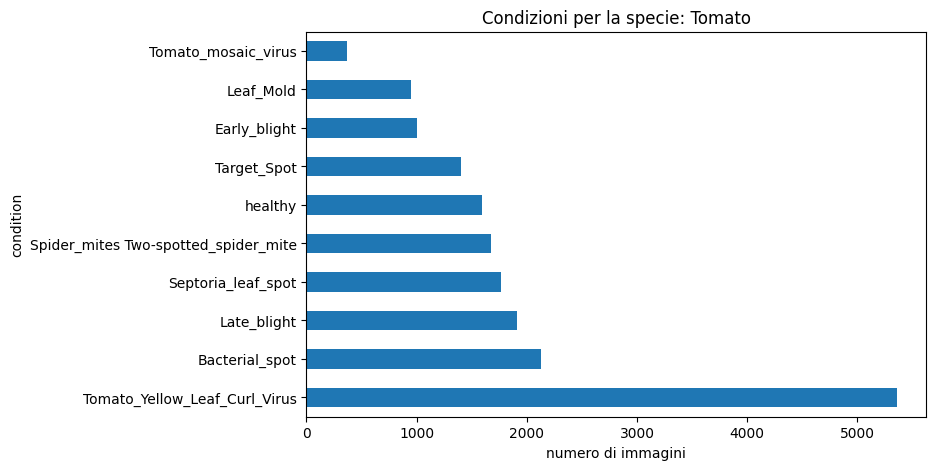

In [13]:
df[df["plant"] == TARGET_PLANT]["condition"].value_counts().plot.barh(
    figsize=(8, 5), title=f"Condizioni per la specie: {TARGET_PLANT}")
plt.xlabel("numero di immagini")
plt.show()

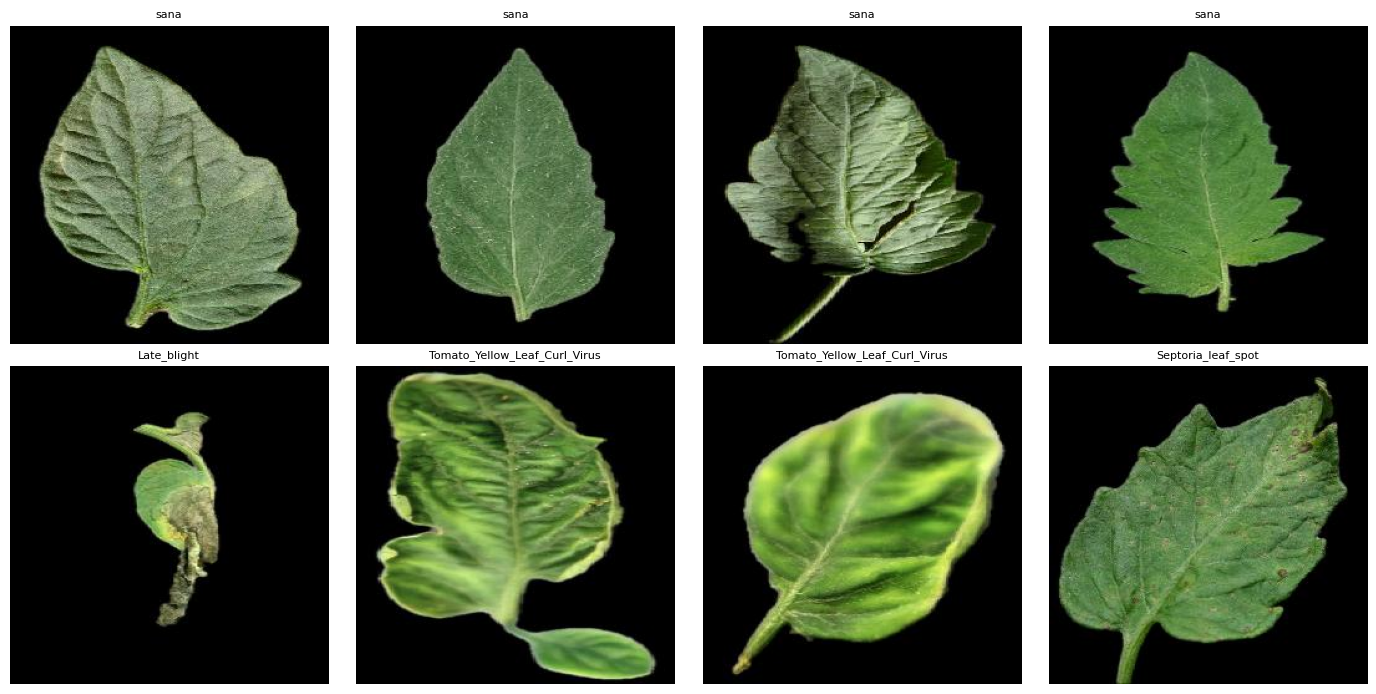

In [14]:
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
examples = pd.concat([
    df[(df.plant == TARGET_PLANT) & (df.healthy)].sample(4, random_state=SEED),
    df[(df.plant == TARGET_PLANT) & (~df.healthy)].sample(4, random_state=SEED),
])
for ax, (_, row) in zip(axes.ravel(), examples.iterrows()):
    ax.imshow(Image.open(row["path"]).convert("RGB"))
    ax.set_title("sana" if row["healthy"] else row["condition"], fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.show()

# Preparazione delle immagini

Le immagini vengono lette, ridimensionate a `IMG_SIZE` e mantenute come pixel grezzi in **[0, 255]** --> la
normalizzazione è affidata a un layer `Rescaling` interno all'autoencoder. Ogni immagine ha forma
`(IMG_SIZE, IMG_SIZE, 3)`, con i canali in ultima posizione come richiesto dai layer convoluzionali di Keras.

In [15]:
def load_images(frame, size=IMG_SIZE):
    """Carica le immagini di un DataFrame come array (N, size, size, 3) in [0, 255]."""
    out = np.empty((len(frame), size, size, 3), dtype="float32")
    for i, path in enumerate(frame["path"].values):
        img = Image.open(path).convert("RGB").resize((size, size))
        out[i] = np.asarray(img, dtype="float32")
    return out

# Autoencoder

L'autoencoder viene addestrato **solo sulle foglie sane** di pomodoro. Impara a comprimere e ricostruire
l'aspetto di una foglia sana. input e target coincidono.

In [16]:
healthy_df = df[(df["plant"] == TARGET_PLANT) & (df["healthy"])]
train_df, val_df = train_test_split(healthy_df, test_size=0.2, random_state=SEED)
print("Foglie sane di addestramento:", len(train_df), "| validazione:", len(val_df))

Foglie sane di addestramento: 1272 | validazione: 319


In [17]:
x_train = load_images(train_df)
x_val   = load_images(val_df)
x_train.shape, x_val.shape

((1272, 128, 128, 3), (319, 128, 128, 3))

Aumento dei dati con riflessioni orizzontali e verticali: triplica gli esempi sani senza introdurre
artefatti, rendendo la ricostruzione più stabile.

In [18]:
x_train_aug = np.concatenate([x_train, x_train[:, :, ::-1, :], x_train[:, ::-1, :, :]], axis=0)
x_train_aug.shape

(3816, 128, 128, 3)

## Architettura

- **Encoder**: blocchi `Conv2D` + `MaxPooling2D`, risoluzione **128 → 64 → 32 → 16 → 8**, infine una
  convoluzione che riduce i canali al bottleneck.
- **Decoder**: simmetrico, `UpSampling2D` + `Conv2D`, risoluzione **8 → 16 → 32 → 64 → 128**; l'ultimo layer
  produce 3 canali con `leaky_relu` e un `Rescaling(255)` riporta i pixel in [0, 255]. La `leaky_relu`
  gestisce lo sfondo scuro delle immagini segmentate e, mantenendo sempre un piccolo gradiente.

In [19]:
encoder = Sequential(
    [
        Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
        Rescaling(1 / 255),
        Conv2D(32, 3, padding="same", activation=leaky_relu),  MaxPooling2D(),
        Conv2D(64, 3, padding="same", activation=leaky_relu),  MaxPooling2D(),
        Conv2D(128, 3, padding="same", activation=leaky_relu), MaxPooling2D(),
        Conv2D(128, 3, padding="same", activation=leaky_relu), MaxPooling2D(),
        Conv2D(BOTTLENECK_CH, 3, padding="same", activation=leaky_relu),
    ],
    name="encoder",
)

In [20]:
decoder = Sequential(
    [
        Input(shape=(8, 8, BOTTLENECK_CH)),
        Conv2D(128, 3, padding="same", activation=leaky_relu), UpSampling2D(),
        Conv2D(128, 3, padding="same", activation=leaky_relu), UpSampling2D(),
        Conv2D(64, 3, padding="same", activation=leaky_relu),  UpSampling2D(),
        Conv2D(32, 3, padding="same", activation=leaky_relu),  UpSampling2D(),
        Conv2D(3, 3, padding="same", activation=leaky_relu),
        Rescaling(255.0),
    ],
    name="decoder",
)

In [21]:
autoencoder = Sequential([encoder, decoder])
autoencoder.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder (Sequential)            │ (None, 8, 8, 32)       │       277,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Sequential)            │ (None, 128, 128, 3)    │       277,699 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 555,427 (2.12 MB)

 Trainable params: 555,427 (2.12 MB)

 Non-trainable params: 0 (0.00 B)

## Addestramento

Loss `MeanSquaredError` tra immagine originale e ricostruita; metrica `MeanAbsoluteError`. `EarlyStopping`
interrompe quando la loss di validazione smette di migliorare e ripristina i pesi migliori.

In [ ]:
autoencoder.compile(
    optimizer=Adam(learning_rate=5e-4, clipnorm=1.0), 
    loss=MeanSquaredError(), 
    metrics=[MeanAbsoluteError()]
    )

In [23]:
callbacks = [
    EarlyStopping(patience=8, restore_best_weights=True, monitor="val_loss"),
    ModelCheckpoint("ckpt/autoencoder.weights.h5", save_weights_only=True, save_best_only=True, monitor="val_loss"),
]

In [24]:
history = autoencoder.fit(
    x=x_train_aug, y=x_train_aug,
    epochs=100, batch_size=32, shuffle=True,
    validation_data=(x_val, x_val),
    callbacks=callbacks,
)

Epoch 1/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - loss: 1082.7179 - mean_absolute_error: 18.4915 - val_loss: 544.9526 - val_mean_absolute_error: 12.6995
Epoch 2/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 6s 53ms/step - loss: 489.1300 - mean_absolute_error: 11.9786 - val_loss: 433.2721 - val_mean_absolute_error: 11.0789
Epoch 3/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - loss: 422.1180 - mean_absolute_error: 11.0314 - val_loss: 394.7867 - val_mean_absolute_error: 10.5407
Epoch 4/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - loss: 387.0085 - mean_absolute_error: 10.4976 - val_loss: 372.0054 - val_mean_absolute_error: 10.1627
Epoch 5/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - loss: 353.8488 - mean_absolute_error: 9.9363 - val_loss: 327.6944 - val_mean_absolute_error: 9.4088
Epoch 6/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - loss: 316.6779 - mean_absolute_error: 9.2354 - val_loss: 309.3692 - val_mean_absolute_error: 9.1783
Epoch 7/100
120/120 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step -

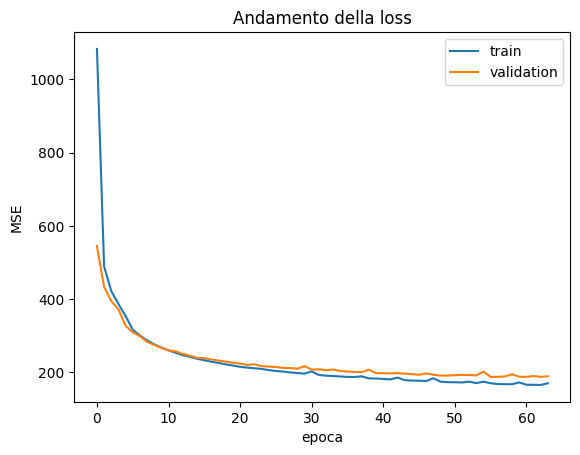

In [25]:
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="validation")
plt.xlabel("epoca"); plt.ylabel("MSE"); plt.title("Andamento della loss"); plt.legend()
plt.show()

## Ricostruzione delle foglie sane

Confronto tra foglie sane originali e la loro ricostruzione. Grazie al bottleneck convoluzionale, forma,
colore e venature principali sono riconoscibili e i contorni più definiti.

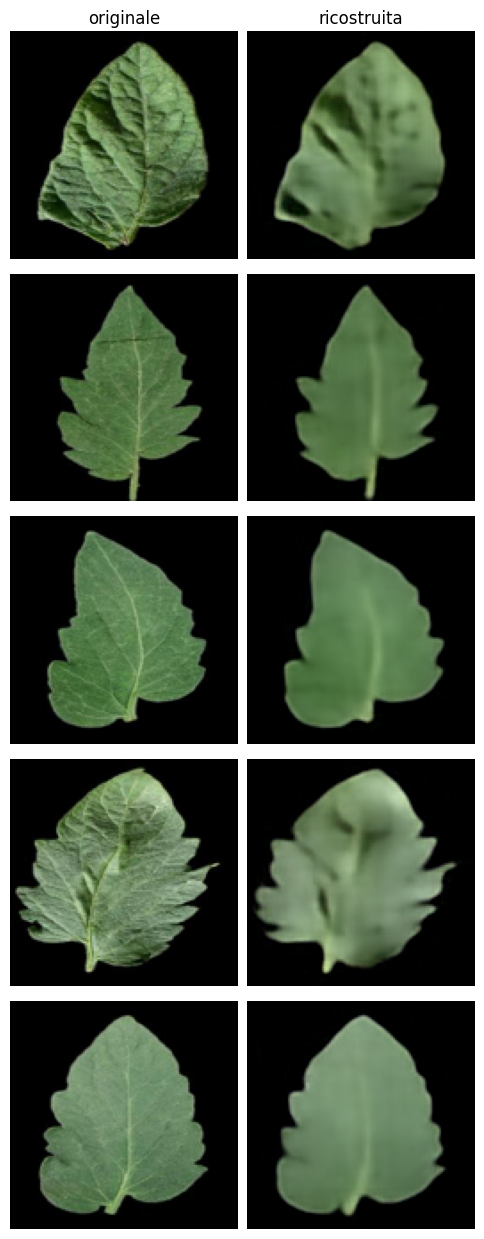

In [26]:
def show_reconstructions(model, images, n=5):
    idxs = random.sample(range(len(images)), n)
    sample = images[idxs]
    recon = model.predict(sample, verbose=0)
    fig, axes = plt.subplots(n, 2, figsize=(5, 2.5 * n))
    for row in range(n):
        axes[row, 0].imshow((sample[row] / 255).clip(0, 1))
        axes[row, 1].imshow((recon[row] / 255).clip(0, 1))
        axes[row, 0].axis("off"); axes[row, 1].axis("off")
    axes[0, 0].set_title("originale"); axes[0, 1].set_title("ricostruita")
    plt.tight_layout(); plt.show()

show_reconstructions(autoencoder, x_val, n=5)

# Classificazione (XGBoost)

**Le caratteristiche.** Ogni foglia passa nell'encoder già addestrato, che la riassume nel bottleneck
`8 x 8 x BOTTLENECK_CH`; appiattito, diventa la riga di numeri su cui XGBoost impara a distinguere le malattie.

In [34]:
parts = []
for condition, group in df[df["plant"] == TARGET_PLANT].groupby("condition"):
    parts.append(group.sample(n=min(250, len(group)), random_state=SEED))
sup_df = pd.concat(parts).reset_index(drop=True)
sup_df["condition"].value_counts()

condition
Bacterial_spot                          250
Early_blight                            250
Late_blight                             250
Leaf_Mold                               250
Septoria_leaf_spot                      250
Spider_mites Two-spotted_spider_mite    250
Target_Spot                             250
Tomato_Yellow_Leaf_Curl_Virus           250
Tomato_mosaic_virus                     250
healthy                                 250
Name: count, dtype: int64

In [35]:
x_sup = load_images(sup_df)
features = encoder.predict(x_sup, verbose=0)
X = features.reshape(len(features), -1)   # appiattisce il bottleneck spaziale
X.shape

(2500, 2048)

In [36]:
import gc, torch
del x_sup
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

In [37]:
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(sup_df["condition"].values)
list(label_encoder.classes_)

['Bacterial_spot',
 'Early_blight',
 'Late_blight',
 'Leaf_Mold',
 'Septoria_leaf_spot',
 'Spider_mites Two-spotted_spider_mite',
 'Target_Spot',
 'Tomato_Yellow_Leaf_Curl_Virus',
 'Tomato_mosaic_virus',
 'healthy']

Suddivisione stratificata in train (60%), validation (20%) e test (20%)

In [38]:
X_work, X_test, y_work, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_work, y_work, test_size=0.25, random_state=SEED, stratify=y_work)
print("train:", len(X_train), "| validation:", len(X_val), "| test:", len(X_test))

train: 1500 | validation: 500 | test: 500


## Iperparametri con Optuna

Si cerca la combinazione di iperparametri che massimizza l'accuratezza sul validation, con ottimizzazione
bayesiana (Optuna). L'early stopping limita il numero di alberi.

In [39]:
def objective(trial):
    params = {
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
    }
    model = XGBClassifier(
        n_estimators=600, eval_metric="mlogloss", early_stopping_rounds=20,
        tree_method="hist", device="cpu", n_jobs=-1, random_state=SEED, **params,
    )
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    return accuracy_score(y_val, model.predict(X_val))

In [40]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20, show_progress_bar=True)
study.best_params

  0%|          | 0/20 [00:00<?, ?it/s]

{'max_depth': 7,
 'learning_rate': 0.027427372098289285,
 'subsample': 0.7931667934487532,
 'colsample_bytree': 0.8093237847157496,
 'reg_lambda': 0.030881360667070173}

In [41]:
model = XGBClassifier(
    n_estimators=600, eval_metric="mlogloss", early_stopping_rounds=20,
    tree_method="hist", device="cpu", n_jobs=-1, random_state=SEED, **study.best_params,
)
model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8093237847157496
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",'cpu'
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",20
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import lo

## Valutazione

L'**accuratezza** è la frazione di foglie classificate correttamente sul test set.

In [45]:
y_pred = model.predict(X_test)
print("Accuratezza sul test:", round(accuracy_score(y_test, y_pred), 3))

Accuratezza sul test: 0.702


La **matrice di confusione** mostra, per ogni malattia reale (riga), come sono state classificate le sue
foglie (colonna). La diagonale contiene le predizioni corrette; le celle fuori diagonale sono gli errori e
rivelano *quali* malattie si confondono tra loro.

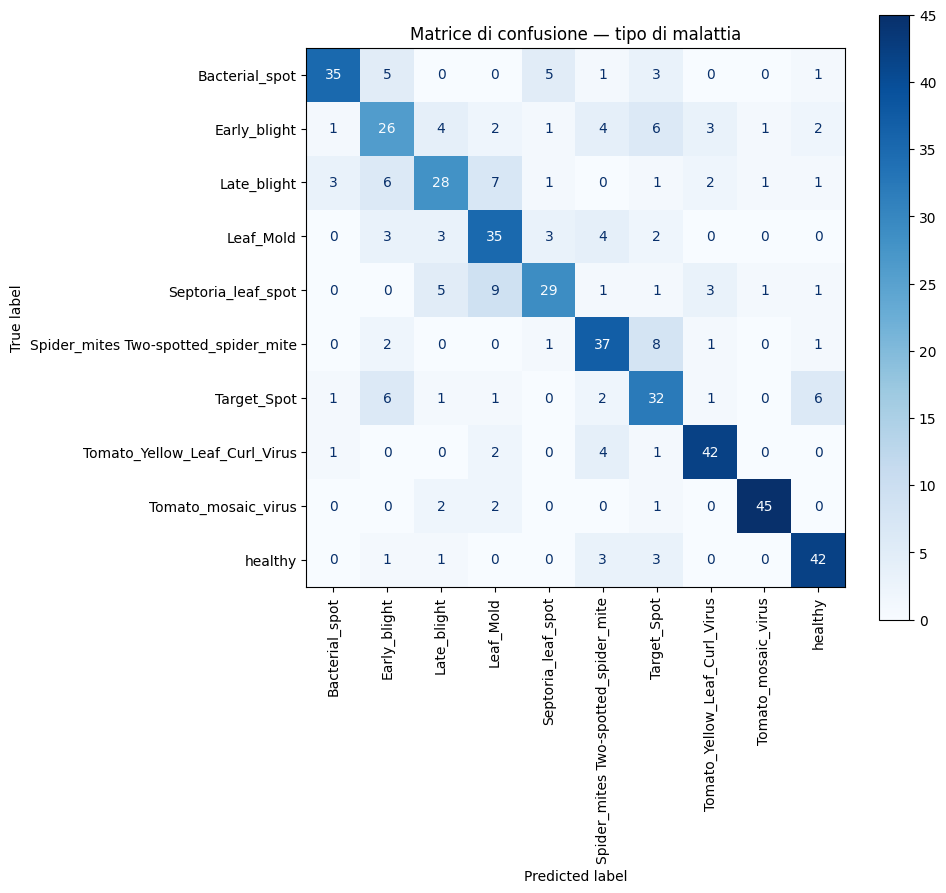

In [43]:
_, ax = plt.subplots(1, 1, figsize=(10, 9))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=label_encoder.classes_,
    cmap="Blues", ax=ax, xticks_rotation=90,
)
ax.set_title("Matrice di confusione — tipo di malattia")
plt.tight_layout(); plt.show()

In [44]:
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

                                      precision    recall  f1-score   support

                      Bacterial_spot       0.85      0.70      0.77        50
                        Early_blight       0.53      0.52      0.53        50
                         Late_blight       0.64      0.56      0.60        50
                           Leaf_Mold       0.60      0.70      0.65        50
                  Septoria_leaf_spot       0.72      0.58      0.64        50
Spider_mites Two-spotted_spider_mite       0.66      0.74      0.70        50
                         Target_Spot       0.55      0.64      0.59        50
       Tomato_Yellow_Leaf_Curl_Virus       0.81      0.84      0.82        50
                 Tomato_mosaic_virus       0.94      0.90      0.92        50
                             healthy       0.78      0.84      0.81        50

                            accuracy                           0.70       500
                           macro avg       0.71      0.70     